# Chronos-2 — Electricity Load Forecasting
**Darekar, Kim, Saxena | University of Trier | RCS SS2026**

Run cells **top to bottom**. Each section is one scenario from the Exposé.

In [22]:
# Add src/ to path so notebook can import our modules
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "src"))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
%matplotlib inline

from chronos import Chronos2Pipeline

from config       import RESULTS_DIR, DATA_DIR, TARGET_COL, TIMESTAMP_COL, MODEL_ID
from data_loader  import load_panama, get_covariate_cols, get_city_cols
from metrics      import evaluate, save_results
from plots        import plot_eda, plot_forecast, plot_stl, plot_summary
from scenarios    import run_s1, run_s2, run_s3a, run_s3b, run_s4

print("All imports OK")
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {'cuda' if torch.cuda.is_available() else 'cpu'}")

All imports OK
PyTorch  : 2.11.0+cpu
Device   : cpu


## 1 — Load Data

Looking for file at: /content/drive/MyDrive/RCS_time_series_forecasting_electric_load/panama/data/raw/continuous dataset.csv
File exists: True
Loaded 48,048 rows
Columns: ['datetime', 'nat_demand', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc', 'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav', 'TQL_dav', 'W2M_dav', 'Holiday_ID', 'holiday', 'school']

train rows : 48,024
test rows  : 24
test window: 2020-06-26 01:00:00 → 2020-06-27 00:00:00

Weather cols  : []
City cols     : ['T2M_toc', 'T2M_san', 'T2M_dav']
Covariate cols: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend']


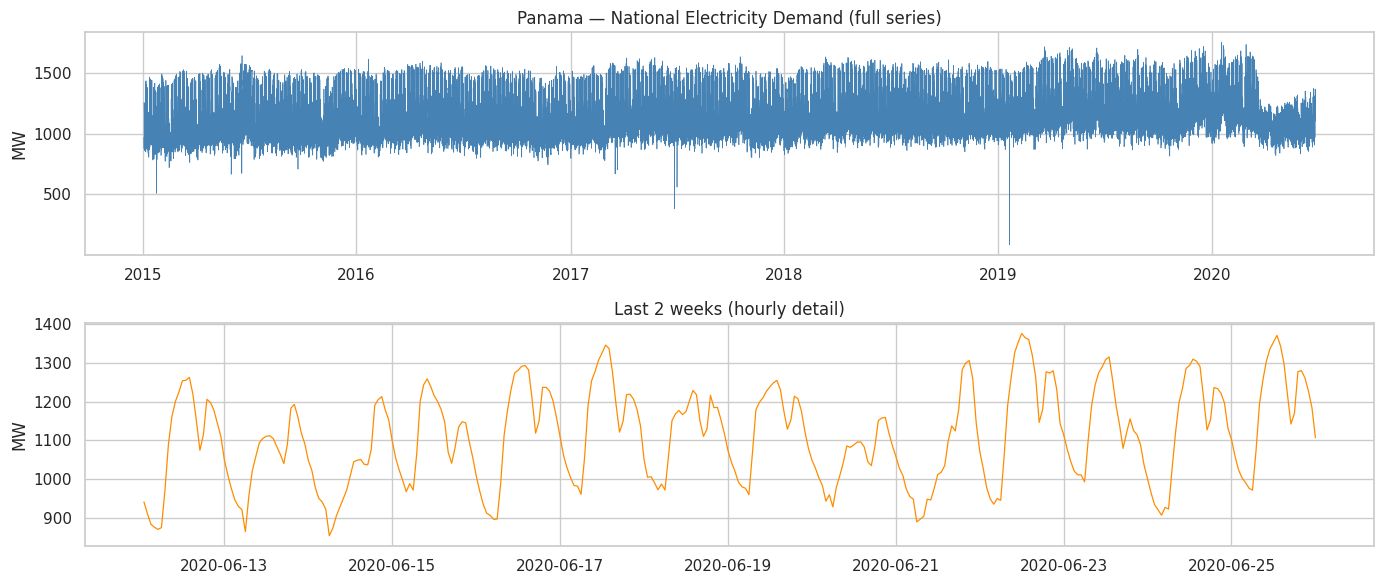

EDA plot saved!


,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,...,Holiday_ID,holiday,school,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,is_weekend
48021,2020-06-25 22:00:00,1226.9634,27.055719,0.020349,0.028793,14.384241,25.555719,0.019395,0.069366,3.038831,...,0,0,1,-0.500000,0.866025,0.433884,-0.900969,1.224647e-16,-1.0,0.0
48022,2020-06-25 23:00:00,1184.3443,26.956049,0.020326,0.032501,14.972072,25.315424,0.019235,0.067352,3.193245,...,0,0,1,-0.258819,0.965926,0.433884,-0.900969,1.224647e-16,-1.0,0.0
48023,2020-06-26 00:00:00,1106.9260,26.861566,0.020318,0.038712,14.991609,25.127191,0.019090,0.073853,3.157133,...,0,0,1,0.000000,1.000000,-0.433884,-0.900969,1.224647e-16,-1.0,0.0


In [23]:
from pathlib import Path

# Hardcode the data path directly — bypasses any config.py path issues
DATA_PATH = DATA_DIR / "raw" / "continuous dataset.csv"

print("Looking for file at:", DATA_PATH)
print("File exists:", DATA_PATH.exists())

# Load raw CSV
df_raw = pd.read_csv(DATA_PATH, parse_dates=["datetime"])
df_raw = df_raw.sort_values("datetime").reset_index(drop=True)
df_raw = df_raw.dropna(subset=["nat_demand"]).ffill()

print(f"Loaded {len(df_raw):,} rows")
print(f"Columns: {list(df_raw.columns)}")

# Add calendar features
df_raw["hour_sin"]   = np.sin(2 * np.pi * df_raw["datetime"].dt.hour / 24)
df_raw["hour_cos"]   = np.cos(2 * np.pi * df_raw["datetime"].dt.hour / 24)
df_raw["dow_sin"]    = np.sin(2 * np.pi * df_raw["datetime"].dt.dayofweek / 7)
df_raw["dow_cos"]    = np.cos(2 * np.pi * df_raw["datetime"].dt.dayofweek / 7)
df_raw["month_sin"]  = np.sin(2 * np.pi * df_raw["datetime"].dt.month / 12)
df_raw["month_cos"]  = np.cos(2 * np.pi * df_raw["datetime"].dt.month / 12)
df_raw["is_weekend"] = (df_raw["datetime"].dt.dayofweek >= 5).astype(float)

# Split train / test (last 24 hours = test)
PREDICTION_LENGTH = 24
test_df  = df_raw.tail(PREDICTION_LENGTH).copy().reset_index(drop=True)
train_df = df_raw.iloc[:-PREDICTION_LENGTH].copy().reset_index(drop=True)
y_true   = test_df["nat_demand"].values

print(f"\ntrain rows : {len(train_df):,}")
print(f"test rows  : {len(test_df)}")
print(f"test window: {test_df['datetime'].iloc[0]} → {test_df['datetime'].iloc[-1]}")

# Covariate columns
WEATHER_COLS   = [c for c in ["T2M","QV2M","TQL","W2M","PS"] if c in df_raw.columns]
CALENDAR_COLS  = ["hour_sin","hour_cos","dow_sin","dow_cos","month_sin","month_cos","is_weekend"]
CITY_COLS      = [c for c in ["T2M_toc","T2M_san","T2M_dav"] if c in df_raw.columns]
COVARIATE_COLS = WEATHER_COLS + CALENDAR_COLS

TARGET_COL    = "nat_demand"
TIMESTAMP_COL = "datetime"
SERIES_ID     = "panama_national"
# RESULTS_DIR   = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

print(f"\nWeather cols  : {WEATHER_COLS}")
print(f"City cols     : {CITY_COLS}")
print(f"Covariate cols: {COVARIATE_COLS}")

# Quick EDA plot
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(train_df["datetime"], train_df["nat_demand"], lw=0.5, color="steelblue")
axes[0].set_title("Panama — National Electricity Demand (full series)")
axes[0].set_ylabel("MW")
zoom = train_df.tail(24 * 14)
axes[1].plot(zoom["datetime"], zoom["nat_demand"], lw=0.9, color="darkorange")
axes[1].set_title("Last 2 weeks (hourly detail)")
axes[1].set_ylabel("MW")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_demand.png", dpi=150)
plt.show()
print("EDA plot saved!")

train_df.tail(3)

In [26]:
print(train_df)

                 datetime  nat_demand    T2M_toc  QV2M_toc   TQL_toc  \
0     2015-01-03 01:00:00    970.3450  25.865259  0.018576  0.016174   
1     2015-01-03 02:00:00    912.1755  25.899255  0.018653  0.016418   
2     2015-01-03 03:00:00    900.2688  25.937280  0.018768  0.015480   
3     2015-01-03 04:00:00    889.9538  25.957544  0.018890  0.016273   
4     2015-01-03 05:00:00    893.6865  25.973840  0.018981  0.017281   
...                   ...         ...        ...       ...       ...   
48019 2020-06-25 20:00:00   1279.2819  27.305139  0.020456  0.024117   
48020 2020-06-25 21:00:00   1260.8193  27.156305  0.020402  0.027321   
48021 2020-06-25 22:00:00   1226.9634  27.055719  0.020349  0.028793   
48022 2020-06-25 23:00:00   1184.3443  26.956049  0.020326  0.032501   
48023 2020-06-26 00:00:00   1106.9260  26.861566  0.020318  0.038712   

         W2M_toc    T2M_san  QV2M_san   TQL_san    W2M_san  ...  Holiday_ID  \
0      21.850546  23.482446  0.017272  0.001855  10.3289

In [27]:
print(test_df)

              datetime  nat_demand    T2M_toc  QV2M_toc   TQL_toc    W2M_toc  \
0  2020-06-26 01:00:00   1068.2532  26.784082  0.020272  0.046677  14.937148   
1  2020-06-26 02:00:00   1040.0120  26.753137  0.020204  0.054642  15.810860   
2  2020-06-26 03:00:00   1016.4073  26.723810  0.020173  0.061768  17.046579   
3  2020-06-26 04:00:00   1000.7215  26.713770  0.020127  0.071838  17.277417   
4  2020-06-26 05:00:00    997.9285  26.705621  0.020143  0.071289  17.673033   
5  2020-06-26 06:00:00    998.4030  26.796594  0.020265  0.070251  18.499934   
6  2020-06-26 07:00:00   1063.6294  27.277551  0.020448  0.071655  20.278820   
7  2020-06-26 08:00:00   1145.1510  27.841455  0.020341  0.101990  18.909966   
8  2020-06-26 09:00:00   1173.6152  28.497858  0.020257  0.150574  16.308290   
9  2020-06-26 10:00:00   1191.1005  28.736963  0.020028  0.152466  14.087005   
10 2020-06-26 11:00:00   1192.4966  28.873804  0.019975  0.137573  13.182539   
11 2020-06-26 12:00:00   1208.1201  28.8

## 2 — Load Chronos-2
Downloads ~700 MB on first run, cached locally after that.

In [24]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

pipeline = Chronos2Pipeline.from_pretrained(
    MODEL_ID,                     # "amazon/chronos-2"  (set in config.py)
    device_map = DEVICE,
    torch_dtype = torch.bfloat16, # use float32 if you get dtype errors on CPU
)

print(f"Loaded {MODEL_ID} on {DEVICE}")

config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loaded amazon/chronos-2 on cpu


---
## S1 — Univariate Baseline (zero-shot)
Chronos-2 on raw demand only — **reference point for RQ1.1**.

In [25]:
out_s1 = run_s1(pipeline, train_df)
res_s1 = evaluate(y_true, out_s1["y_pred"], out_s1["label"])
plot_forecast(
    y_true, out_s1["y_pred"],
    title       = "S1 — Univariate Baseline (zero-shot)",
    filename    = "s1_univariate.png",
    results_dir = RESULTS_DIR,
    q_lo        = out_s1["q_lo"],
    q_hi        = out_s1["q_hi"],
)
all_results = [res_s1]
print(res_s1)  # ← add this line


[S1] Univariate Baseline ...
  [S1_Univariate]  MAPE = 6.9078%   RMSE = 89.4720 MW
[plot]  /content/drive/MyDrive/RCS_time_series_forecasting_electric_load/panama/results/s1_univariate.png
{'scenario': 'S1_Univariate', 'MAPE_%': 6.907764, 'RMSE_MW': 89.472032}


---
## S2 — Covariate-Informed Forecasting
Weather (T2M, QV2M, W2M, PS) + calendar features via `predict_df(future_df=...)` — **RQ1.1, RQ1.2**.

In [ ]:
out_s2 = run_s2(pipeline, train_df, test_df, COVARIATE_COLS)

res_s2 = evaluate(y_true, out_s2["y_pred"], out_s2["label"])

plot_forecast(
    y_true, out_s2["y_pred"],
    title       = "S2 — Covariate-Informed Forecasting",
    filename    = "s2_covariate.png",
    results_dir = RESULTS_DIR,
    q_lo        = out_s2["q_lo"],
    q_hi        = out_s2["q_hi"],
)

all_results.append(res_s2)

---
## S3a — Cross-City Learning
Feed per-city temperature series (Tocumen, Santiago, David) alongside national demand — **RQ1.1, RQ1.2**.

In [ ]:
out_s3a = run_s3a(pipeline, train_df, test_df, CITY_COLS, COVARIATE_COLS)

if out_s3a is not None:
    res_s3a = evaluate(y_true, out_s3a["y_pred"], out_s3a["label"])
    plot_forecast(
        y_true, out_s3a["y_pred"],
        title       = "S3a — Cross-City Learning",
        filename    = "s3a_crosscity.png",
        results_dir = RESULTS_DIR,
        q_lo        = out_s3a["q_lo"],
        q_hi        = out_s3a["q_hi"],
    )
    all_results.append(res_s3a)

---
## S3b — STL Decomposition Cross-Learning
Decompose demand → trend + seasonal (24 h) + residual, feed all as separate series — **RQ1.1, RQ1.2**.

In [ ]:
out_s3b = run_s3b(pipeline, train_df, test_df, COVARIATE_COLS)

# Visualise the STL decomposition itself
plot_stl(
    out_s3b["trend"], out_s3b["seasonal"], out_s3b["residual"],
    train_df[TARGET_COL].values,
    RESULTS_DIR,
)

# Evaluate both reconstruction variants
res_s3b_add = evaluate(y_true, out_s3b["y_pred_additive"], out_s3b["label_additive"])
res_s3b_dir = evaluate(y_true, out_s3b["y_pred_direct"],   out_s3b["label_direct"])

# Plot the better one
best_s3b_pred  = (
    out_s3b["y_pred_additive"]
    if res_s3b_add["MAPE_%"] < res_s3b_dir["MAPE_%"]
    else out_s3b["y_pred_direct"]
)
best_s3b_label = (
    out_s3b["label_additive"]
    if res_s3b_add["MAPE_%"] < res_s3b_dir["MAPE_%"]
    else out_s3b["label_direct"]
)

plot_forecast(
    y_true, best_s3b_pred,
    title       = f"S3b — STL Decomposition ({best_s3b_label})",
    filename    = "s3b_stl_forecast.png",
    results_dir = RESULTS_DIR,
    q_lo        = out_s3b["q_lo"],
    q_hi        = out_s3b["q_hi"],
)

all_results.extend([res_s3b_add, res_s3b_dir])

---
## S4 — Ensemble-Based Forecasting
10 weather realisations → average (mirrors Copernicus ERA5 EDA) — **RQ1.1, RQ1.2**.

In [ ]:
out_s4 = run_s4(pipeline, train_df, test_df, COVARIATE_COLS)

res_s4 = evaluate(y_true, out_s4["y_pred"], out_s4["label"])

plot_forecast(
    y_true, out_s4["y_pred"],
    title        = "S4 — Ensemble Forecasting (10 weather realisations)",
    filename     = "s4_ensemble.png",
    results_dir  = RESULTS_DIR,
    ensemble_std = out_s4["ensemble_std"],
)

all_results.append(res_s4)

---
## Results Summary — RQ1 & RQ2

In [ ]:
results_df = save_results(all_results, RESULTS_DIR, dataset="Panama")

print("\n=== FINAL RESULTS ===")
display(results_df.drop(columns="dataset").set_index("scenario"))

print(f"\nBest MAPE : {results_df.loc[results_df['MAPE_%'].idxmin(),  'scenario']}")
print(f"Best RMSE : {results_df.loc[results_df['RMSE_MW'].idxmin(), 'scenario']}")

In [ ]:
# Summary bar chart — saved to results/scenario_comparison.png
plot_summary(results_df, RESULTS_DIR)